In [39]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [40]:
# File names
all_events = "momenta_all_events.txt"
delayed_events = "momenta_delayed_events.txt"
direct_events = "momenta_direct_events.txt"

# File used for the first PCA inspection
file = direct_events

In [41]:
# Column order in the input files
all_columns = [
    "p1x", "p1y", "p1z",
    "p2x", "p2y", "p2z",
    "p3x", "p3y", "p3z",
    "p4x", "p4y", "p4z",
]

# PCA is performed only for the three electrons.
# Particle 1 is the ion/core and is not included in the PCA input.
electron_columns = [
    "p2x", "p2y", "p2z",
    "p3x", "p3y", "p3z",
    "p4x", "p4y", "p4z",
]

# Read the selected dataset
df = pd.read_csv(file, sep=",", header=None, names=all_columns)
df_e = df[electron_columns]

df_e.head()

,p2x,p2y,p2z,p3x,p3y,p3z,p4x,p4y,p4z
0,-0.142062,0.242653,-3.292359,-0.024158,-0.239607,-1.971315,-0.443883,0.419737,-1.224288
1,0.033526,0.156105,3.926861,0.183437,-0.815696,2.883397,0.212362,-0.014222,2.147512
2,0.873104,-1.909317,1.519567,0.495212,0.229296,1.858649,0.048404,0.312495,3.558018
3,0.012657,-0.369678,-1.116379,-0.188129,0.209716,1.236401,-1.133377,-0.090108,-2.939693
4,-0.684369,0.738532,0.308961,0.156100,0.173678,-2.159729,1.191435,1.186332,-2.684345


In [42]:
# Number of events and PCA input variables
df_e.shape

(1695, 9)

In [43]:
# Basic statistics of the electron momentum components
df_e.describe()

,p2x,p2y,p2z,p3x,p3y,p3z,p4x,p4y,p4z
count,1695.000000,1695.000000,1695.000000,1695.000000,1695.000000,1695.000000,1695.000000,1695.000000,1695.000000
mean,-0.002203,0.027078,0.131623,-0.002806,0.028091,0.091779,0.019352,0.007965,0.096473
std,0.604946,0.613694,2.664659,0.596160,0.596162,2.688479,0.924376,0.895538,2.652450
min,-2.786250,-2.792536,-5.673502,-2.550209,-2.279354,-5.698913,-3.274396,-3.050914,-6.392862
25%,-0.304855,-0.292821,-2.384260,-0.331795,-0.316066,-2.529485,-0.478710,-0.466377,-2.333571
50%,0.008420,0.022195,0.535902,-0.015133,0.036691,0.547270,0.017364,0.000266,0.277928
75%,0.293838,0.333426,2.599603,0.323074,0.362930,2.576064,0.543562,0.475061,2.399661
max,2.579348,2.916854,5.743142,2.173392,2.743771,6.355223,3.153540,3.437597,6.234516


In [44]:
# Missing-value check
# All values should be zero before PCA is performed.
df_e.isna().sum()

p2x    0
p2y    0
p2z    0
p3x    0
p3y    0
p3z    0
p4x    0
p4y    0
p4z    0
dtype: int64

In [45]:
# Standardize every momentum component before PCA.
# StandardScaler gives each input column mean 0 and standard deviation 1,
# so PCA is not dominated only by differences in the numerical scale of columns.
X = df_e.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA in the full 9-dimensional electron-momentum space.
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [46]:
# Explained variance of every principal component
explained = pca.explained_variance_ratio_
cumulative_explained = np.cumsum(explained)

explained_variance = pd.DataFrame({
    "PC": [f"PC{i + 1}" for i in range(len(explained))],
    "explained_variance_ratio": explained,
    "cumulative_explained_variance": cumulative_explained,
})

explained_variance

,PC,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.296699,0.296699
1,PC2,0.126389,0.423088
2,PC3,0.122641,0.545730
3,PC4,0.116577,0.662307
4,PC5,0.113155,0.775462
5,PC6,0.097264,0.872726
6,PC7,0.089999,0.962725
7,PC8,0.022677,0.985403
8,PC9,0.014597,1.000000


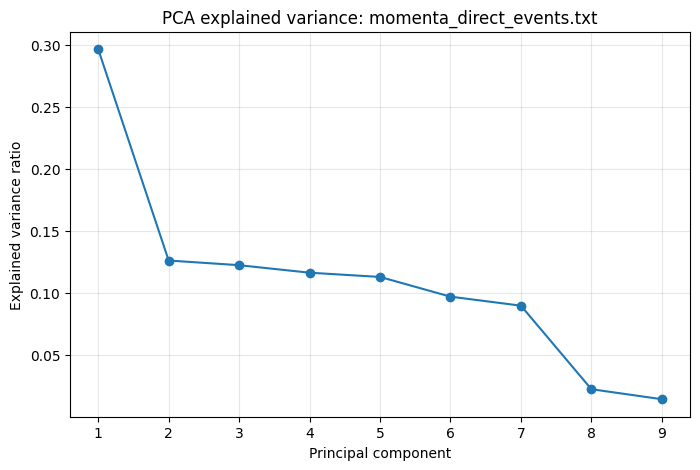

In [47]:
# Explained variance ratio for each principal component
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained) + 1), explained, marker="o")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title(f"PCA explained variance: {file}")
plt.grid(True, alpha=0.3)
plt.show()

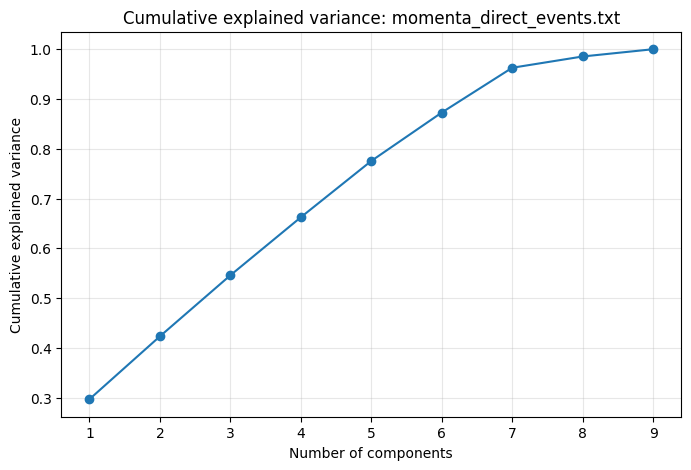

In [48]:
# Cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(1, len(cumulative_explained) + 1),
    cumulative_explained,
    marker="o",
)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title(f"Cumulative explained variance: {file}")
plt.grid(True, alpha=0.3)
plt.show()

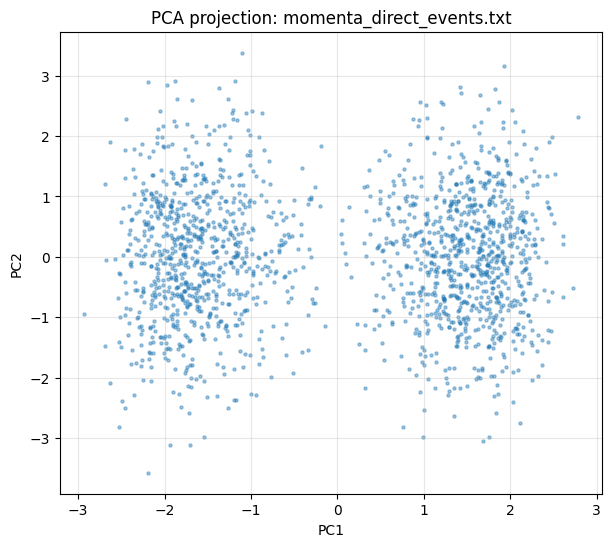

In [49]:
# Projection of the events onto the first two principal components
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA projection: {file}")
plt.grid(True, alpha=0.3)
plt.show()

In [50]:
# Loadings: coefficients of the original momentum components
# in every principal-component direction.
loadings = pd.DataFrame(
    pca.components_.T,
    index=electron_columns,
    columns=[f"PC{i + 1}" for i in range(len(electron_columns))],
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
p2x,0.015236,0.036494,-0.260518,-0.521164,0.667273,0.422002,0.187848,0.015238,0.009769
p2y,-0.060748,-0.404988,0.203166,0.498251,0.509980,-0.239530,0.474611,0.000494,-0.007366
p2z,0.580442,-0.028218,0.017893,0.004391,0.010935,0.003748,0.017537,-0.402379,-0.706825
p3x,-0.003077,0.110922,-0.521515,0.574587,-0.171477,0.567365,0.184713,-0.000252,-0.011505
p3y,-0.007960,-0.493732,-0.332191,-0.373290,-0.454460,-0.140386,0.529321,0.003773,0.005656
p3z,0.580404,-0.015023,0.007891,0.029784,0.010632,-0.007022,0.023247,-0.401731,0.707011
p4x,-0.007299,-0.167106,0.699130,-0.077784,-0.227538,0.621346,0.197099,0.018927,0.011782
p4y,-0.002081,0.741348,0.139070,-0.053269,-0.081888,-0.190154,0.620616,-0.010621,-0.008946
p4z,0.567596,-0.005860,0.004385,0.029053,0.004086,-0.025216,0.017282,0.822183,-0.001059


In [51]:
# The longitudinal z-components are the physically relevant part here,
# because the laser polarization axis is z.
# PC1, PC8 and PC9 are inspected because their loadings are dominated by p2z, p3z and p4z.
longitudinal_components = ["p2z", "p3z", "p4z"]
selected_pcs = ["PC1", "PC8", "PC9"]

loadings.loc[longitudinal_components, selected_pcs]

,PC1,PC8,PC9
p2z,0.580442,-0.402379,-0.706825
p3z,0.580404,-0.401731,0.707011
p4z,0.567596,0.822183,-0.001059


In [52]:
# Helper function used to repeat exactly the same PCA procedure
# for another event class without duplicating the analysis code.
def run_pca(file_path):
    data = pd.read_csv(file_path, sep=",", header=None, names=all_columns)
    electron_data = data[electron_columns]

    scaled = StandardScaler().fit_transform(electron_data.values)

    model = PCA()
    scores = model.fit_transform(scaled)

    model_loadings = pd.DataFrame(
        model.components_.T,
        index=electron_columns,
        columns=[f"PC{i + 1}" for i in range(len(electron_columns))],
    )

    model_explained = pd.DataFrame({
        "PC": [f"PC{i + 1}" for i in range(len(electron_columns))],
        "explained_variance_ratio": model.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(model.explained_variance_ratio_),
    })

    return {
        "data": data,
        "electron_data": electron_data,
        "scaled": scaled,
        "scores": scores,
        "model": model,
        "loadings": model_loadings,
        "explained_variance": model_explained,
    }

In [53]:
# Compare the longitudinal PCA directions for direct and delayed events.
# The sign of a PCA eigenvector is arbitrary, so the important information
# is the relative pattern of coefficients, not the overall sign.
result_direct = run_pca(direct_events)
result_delayed = run_pca(delayed_events)

comparison = pd.concat(
    {
        "direct": result_direct["loadings"].loc[longitudinal_components, selected_pcs],
        "delayed": result_delayed["loadings"].loc[longitudinal_components, selected_pcs],
    },
    axis=1,
)

comparison

direct                       delayed                    
          PC1       PC8       PC9       PC1       PC8       PC9
p2z  0.580442 -0.402379 -0.706825  0.544708 -0.644433 -0.479682
p3z  0.580404 -0.401731  0.707011  0.533005  0.695088 -0.429393
p4z  0.567596  0.822183 -0.001059  0.644516 -0.030772  0.761409

In [54]:
# The PCA result motivates three simple longitudinal directions:
#
# P_col = p2z + p3z + p4z
#     collective longitudinal motion of the three electrons
#
# A3 = p3z - (p2z + p4z) / 2
#     deviation of electron 3 from the average of electrons 2 and 4
#
# R24 = p2z - p4z
#     difference between electrons 2 and 4
#
# These variables are used here as an interpretable approximation
# of the longitudinal subspace identified by PCA.
df_all = pd.read_csv(all_events, sep=",", header=None, names=all_columns)

df_all["P_col"] = df_all["p2z"] + df_all["p3z"] + df_all["p4z"]
df_all["A3"] = df_all["p3z"] - (df_all["p2z"] + df_all["p4z"]) / 2
df_all["R24"] = df_all["p2z"] - df_all["p4z"]

df_all[["p2z", "p3z", "p4z", "P_col", "A3", "R24"]].head()

,p2z,p3z,p4z,P_col,A3,R24
0,-3.292359,-1.971315,-1.224288,-6.487961,0.287009,-2.068071
1,3.926861,2.883397,2.147512,8.957770,-0.153789,1.779349
2,1.519567,1.858649,3.558018,6.936233,-0.680144,-2.038451
3,2.763064,-1.576204,3.630922,4.817782,-4.773197,-0.867859
4,1.214373,-0.373770,0.360212,1.200814,-1.161063,0.854160


In [55]:
# Summary statistics of the three proposed longitudinal variables
summary = df_all[["P_col", "A3", "R24"]].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
P_col,3873.0,0.182760,6.246761,-12.575505,-5.456895,0.283859,5.798605,12.931693
A3,3873.0,-0.012382,1.945336,-7.240909,-1.248959,-0.017930,1.190702,6.239870
R24,3873.0,-0.103221,2.177899,-8.056754,-1.551474,-0.089655,1.346683,9.145002


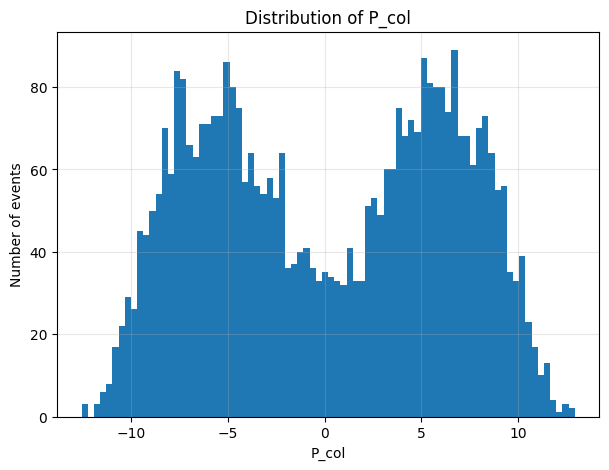

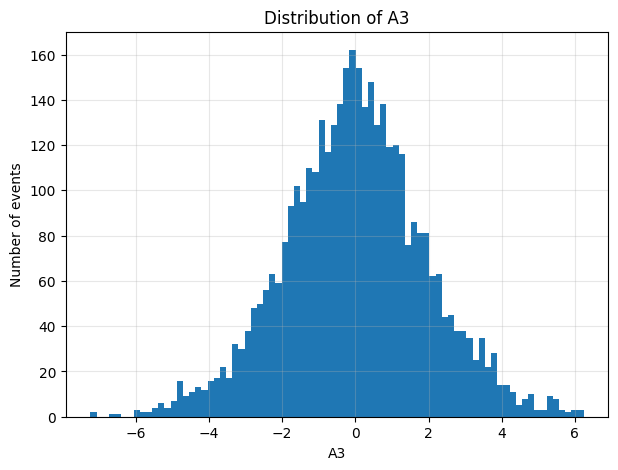

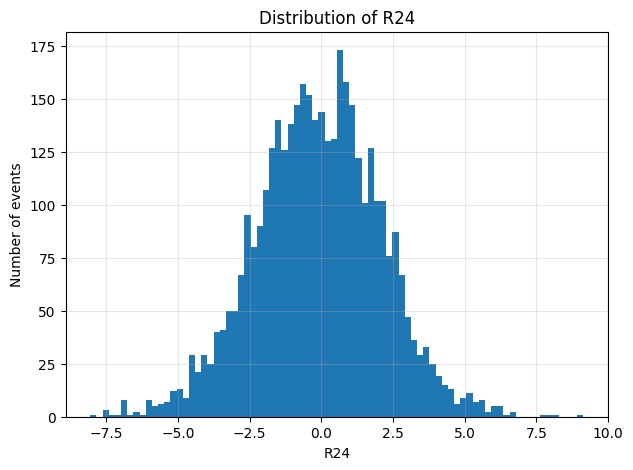

In [56]:
# One-dimensional distributions
for column in ["P_col", "A3", "R24"]:
    plt.figure(figsize=(7, 5))
    plt.hist(df_all[column], bins=80)
    plt.xlabel(column)
    plt.ylabel("Number of events")
    plt.title(f"Distribution of {column}")
    plt.grid(True, alpha=0.3)
    plt.show()

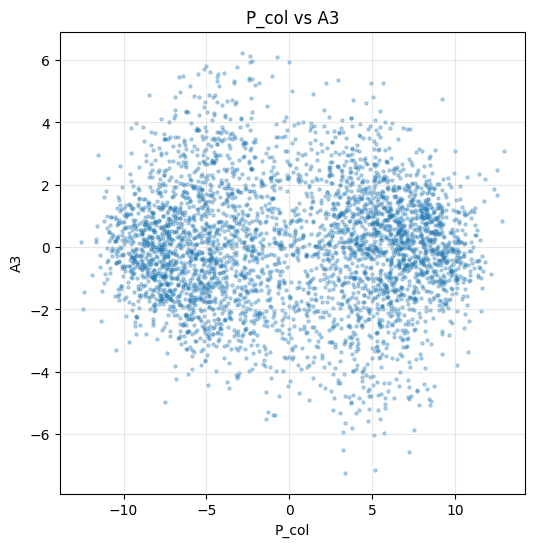

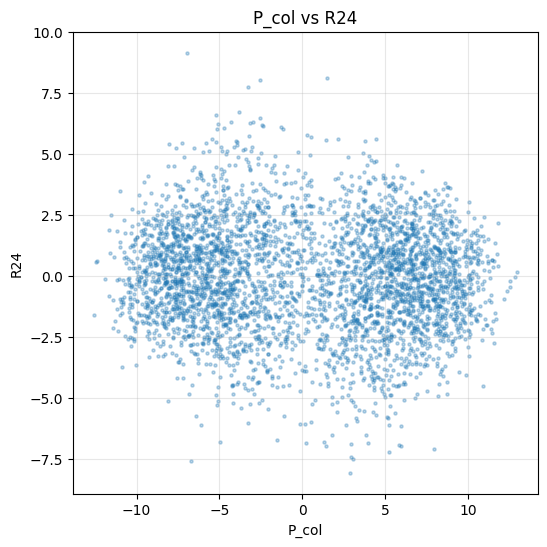

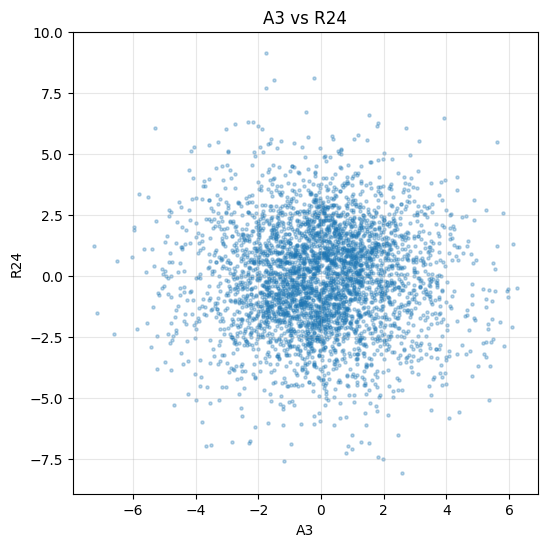

In [57]:
# Pairwise projections of the proposed longitudinal variables
pairs = [
    ("P_col", "A3"),
    ("P_col", "R24"),
    ("A3", "R24"),
]

for x, y in pairs:
    plt.figure(figsize=(6, 6))
    plt.scatter(df_all[x], df_all[y], s=5, alpha=0.3)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.grid(True, alpha=0.3)
    plt.show()